### RFM Analysis
> ***Note*** : R - Recency / F - Frequency / M - Monetary

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset

orders = pd.read_csv('../Data/processed/orders_cleaned.csv')
customers = pd.read_csv('../Data/processed/customers_cleaned.csv')
payments = pd.read_csv('../Data/processed/payments_order_level.csv')

In [2]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99418 entries, 0 to 99417
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99418 non-null  str    
 1   customer_id                    99418 non-null  str    
 2   order_status                   99418 non-null  str    
 3   order_purchase_timestamp       99418 non-null  str    
 4   order_approved_at              99272 non-null  str    
 5   order_delivered_carrier_date   97637 non-null  str    
 6   order_delivered_customer_date  96461 non-null  str    
 7   order_estimated_delivery_date  99418 non-null  str    
 8   weekday                        99418 non-null  str    
 9   hour                           99418 non-null  int64  
 10  month                          99418 non-null  str    
 11  delivery_time                  96455 non-null  float64
 12  late_delivery                  96455 non-null  object 
dt

In [3]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


## Merge 3 dataset

In [4]:
RFM_DF = orders.merge(customers, on='customer_id', how='left').merge(payments, on='order_id', how='left')
RFM_DF.info()

<class 'pandas.DataFrame'>
RangeIndex: 99418 entries, 0 to 99417
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99418 non-null  str    
 1   customer_id                    99418 non-null  str    
 2   order_status                   99418 non-null  str    
 3   order_purchase_timestamp       99418 non-null  str    
 4   order_approved_at              99272 non-null  str    
 5   order_delivered_carrier_date   97637 non-null  str    
 6   order_delivered_customer_date  96461 non-null  str    
 7   order_estimated_delivery_date  99418 non-null  str    
 8   weekday                        99418 non-null  str    
 9   hour                           99418 non-null  int64  
 10  month                          99418 non-null  str    
 11  delivery_time                  96455 non-null  float64
 12  late_delivery                  96455 non-null  object 
 1

## Change type of date into Date/time

In [5]:
# Convert date columns to datetime format
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

RFM_DF[date_cols] = RFM_DF[date_cols].apply(pd.to_datetime)

# Convert late_delivery to boolean and num_payments to integer
RFM_DF['late_delivery'] = RFM_DF['late_delivery'].astype(bool)
RFM_DF['num_payments'] = RFM_DF['num_payments'].astype('Int64')

RFM_DF.info()

<class 'pandas.DataFrame'>
RangeIndex: 99418 entries, 0 to 99417
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99418 non-null  str           
 1   customer_id                    99418 non-null  str           
 2   order_status                   99418 non-null  str           
 3   order_purchase_timestamp       99418 non-null  datetime64[us]
 4   order_approved_at              99272 non-null  datetime64[us]
 5   order_delivered_carrier_date   97637 non-null  datetime64[us]
 6   order_delivered_customer_date  96461 non-null  datetime64[us]
 7   order_estimated_delivery_date  99418 non-null  datetime64[us]
 8   weekday                        99418 non-null  str           
 9   hour                           99418 non-null  int64         
 10  month                          99418 non-null  str           
 11  delivery_time             

In [6]:
print(RFM_DF['order_status'].value_counts())

order_status
delivered      96455
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [7]:
rfm_df = RFM_DF[RFM_DF['order_status'] == 'delivered'].copy()
rfm_df.info()

<class 'pandas.DataFrame'>
Index: 96455 entries, 0 to 99417
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96455 non-null  str           
 1   customer_id                    96455 non-null  str           
 2   order_status                   96455 non-null  str           
 3   order_purchase_timestamp       96455 non-null  datetime64[us]
 4   order_approved_at              96455 non-null  datetime64[us]
 5   order_delivered_carrier_date   96455 non-null  datetime64[us]
 6   order_delivered_customer_date  96455 non-null  datetime64[us]
 7   order_estimated_delivery_date  96455 non-null  datetime64[us]
 8   weekday                        96455 non-null  str           
 9   hour                           96455 non-null  int64         
 10  month                          96455 non-null  str           
 11  delivery_time                  

In [8]:
print(rfm_df['order_status'].value_counts())

order_status
delivered    96455
Name: count, dtype: int64


In [9]:
rfm_df = rfm_df[[
    'customer_unique_id',
    'order_id',
    'order_purchase_timestamp',
    'total_value'
]]
print(rfm_df.shape[1])

4


In [10]:
print(rfm_df.shape)
print(rfm_df.isnull().sum())
print(rfm_df.dtypes)

(96455, 4)
customer_unique_id          0
order_id                    0
order_purchase_timestamp    0
total_value                 1
dtype: int64
customer_unique_id                     str
order_id                               str
order_purchase_timestamp    datetime64[us]
total_value                        float64
dtype: object


In [11]:
# Should every order_id be unique?
print(rfm_df['order_id'].duplicated().sum())

# How many unique customers?
print(rfm_df['customer_unique_id'].nunique())

0
93336


In [12]:
print(rfm_df['total_value'].describe())

# Any zero or negative values?
print(rfm_df[rfm_df['total_value'] <= 0].shape[0])


count    96454.000000
mean       159.857904
std        218.834274
min          9.590000
25%         61.880000
50%        105.280000
75%        176.330000
max      13664.080000
Name: total_value, dtype: float64
0


In [13]:
print(f"Earliest order: {rfm_df['order_purchase_timestamp'].min()}")
print(f"Latest order:   {rfm_df['order_purchase_timestamp'].max()}")
print(f"Date range:     {(rfm_df['order_purchase_timestamp'].max() - rfm_df['order_purchase_timestamp'].min()).days} days")

Earliest order: 2016-09-15 12:16:38
Latest order:   2018-08-29 15:00:37
Date range:     713 days


In [14]:
orders_per_customer = rfm_df.groupby('customer_unique_id')['order_id'].count()
print(orders_per_customer.describe())
print(f"\nCustomers with 1 order:  {(orders_per_customer == 1).sum()}")
print(f"Customers with 2 orders: {(orders_per_customer == 2).sum()}")
print(f"Customers with 3+ orders:{(orders_per_customer >= 3).sum()}")

count    93336.000000
mean         1.033417
std          0.209098
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         15.000000
Name: order_id, dtype: float64

Customers with 1 order:  90536
Customers with 2 orders: 2572
Customers with 3+ orders:228


---
## Fix Missing Value in total_value

In [15]:
# Inspect the row with missing total_value
print(rfm_df[rfm_df['total_value'].isnull()])

# Drop the 1 row with missing total_value (only 1 out of 96,455 — safe to drop)
rfm_df = rfm_df.dropna(subset=['total_value']).reset_index(drop=True)

print(f"\nShape after dropping: {rfm_df.shape}")
print(f"Missing values remaining: {rfm_df.isnull().sum().sum()}")

                     customer_unique_id                          order_id  \
30702  830d5b7aaa3b6f1e9ad63703bec97d23  bfbd0f9bdef84302105ad712db648a6c   

      order_purchase_timestamp  total_value  
30702      2016-09-15 12:16:38          NaN  

Shape after dropping: (96454, 4)
Missing values remaining: 0


---
## RFM Feature Engineering
> Build Recency, Frequency, and Monetary value per customer

In [16]:
# Snapshot date = 1 day after the last order in the dataset
snapshot_date = rfm_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date}")

# Build RFM table — one row per customer
rfm = rfm_df.groupby('customer_unique_id').agg(
    Recency   = ('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('order_id', 'nunique'),
    Monetary  = ('total_value', 'sum')
).reset_index()

print(f"RFM shape: {rfm.shape}")
print(rfm.describe().round(2))

Snapshot date: 2018-08-30 15:00:37
RFM shape: (93335, 4)
        Recency  Frequency  Monetary
count  93335.00   93335.00  93335.00
mean     237.90       1.03    165.20
std      152.55       0.21    226.34
min        1.00       1.00      9.59
25%      114.00       1.00     63.05
50%      219.00       1.00    107.78
75%      346.00       1.00    182.54
max      695.00      15.00  13664.08


## RFM Distributions

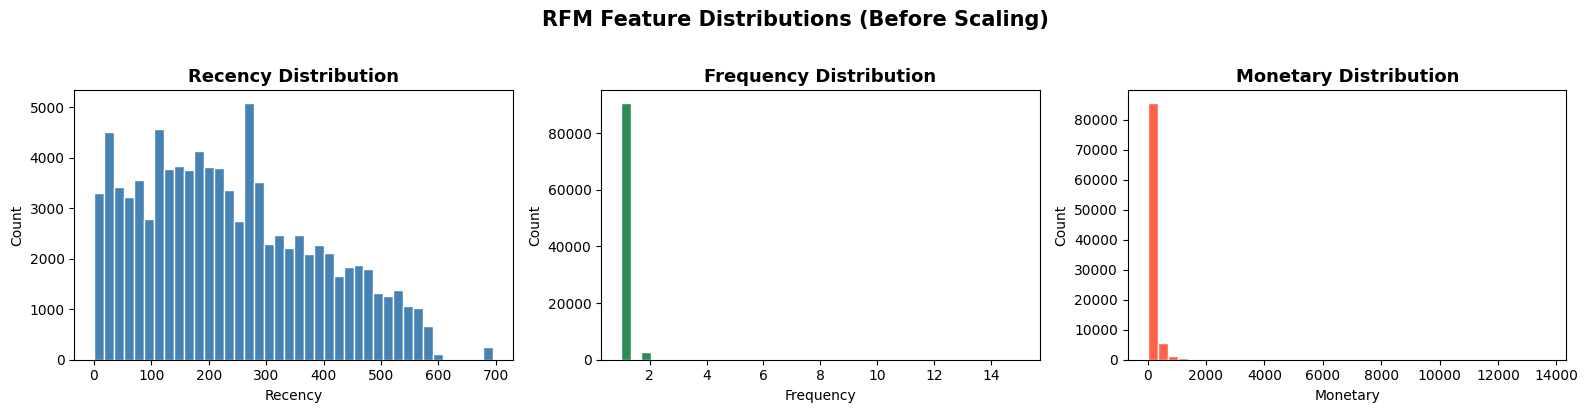

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, color in zip(axes, ['Recency', 'Frequency', 'Monetary'], ['steelblue', 'seagreen', 'tomato']):
    ax.hist(rfm[col], bins=40, color=color, edgecolor='white')
    ax.set_title(f'{col} Distribution', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.suptitle('RFM Feature Distributions (Before Scaling)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Scaling
> Log-transform to reduce skewness, then StandardScaler to normalize all features to the same range

In [19]:
from sklearn.preprocessing import StandardScaler

# Log1p transform to handle right skewness in Frequency and Monetary
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].copy()
rfm_log['Recency']   = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary']  = np.log1p(rfm_log['Monetary'])

# StandardScaler: mean=0, std=1
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

print("Scaled RFM stats (should be ~mean=0, std=1):")
print(rfm_scaled_df.describe().round(3))

Scaled RFM stats (should be ~mean=0, std=1):
         Recency  Frequency   Monetary
count  93335.000  93335.000  93335.000
mean      -0.000      0.000      0.000
std        1.000      1.000      1.000
min       -4.794     -0.170     -2.931
25%       -0.451     -0.170     -0.704
50%        0.244     -0.170     -0.049
75%        0.732     -0.170      0.598
max        1.478     26.948      5.930


---
## Elbow Method — Find Optimal Number of Clusters
> Look for the 'elbow' where inertia stops dropping sharply

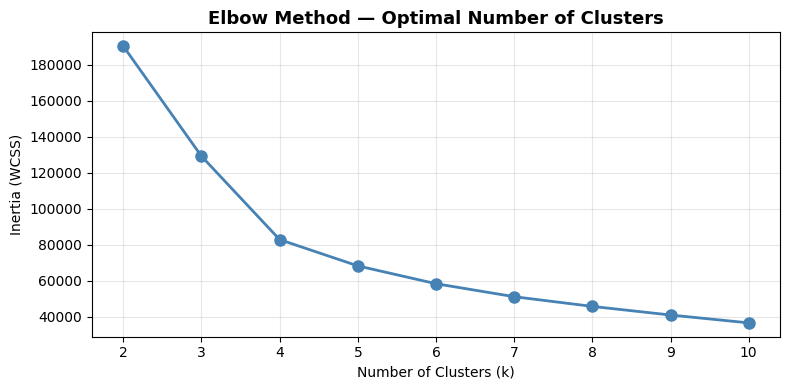

Pick k at the elbow point — where the curve bends and flattens.


In [20]:
from sklearn.cluster import KMeans

inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled_df)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.title('Elbow Method — Optimal Number of Clusters', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Pick k at the elbow point — where the curve bends and flattens.")

---
## K-Means Clustering
> Set K based on the elbow plot above (default: 4)

In [21]:
# Adjust K based on your elbow plot
K = 4

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled_df)

print("Cluster sizes:")
print(rfm['Cluster'].value_counts().sort_index())

Cluster sizes:
Cluster
0    32151
1    42236
2    16148
3     2800
Name: count, dtype: int64


## Cluster Profile — Who is in Each Cluster?

In [22]:
# Mean RFM values per cluster — use this to assign meaningful labels
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
cluster_profile['Count'] = rfm['Cluster'].value_counts().sort_index()
print(cluster_profile.sort_values('Monetary', ascending=False))

         Recency  Frequency  Monetary  Count
Cluster                                     
3         220.26       2.11    308.59   2800
0         272.29       1.00    296.10  32151
2          42.22       1.00    133.29  16148
1         287.70       1.00     68.25  42236


In [23]:
# Label segments after reviewing cluster_profile above:
# Champions  = low Recency (recent), high Frequency, high Monetary
# Promising  = low Recency, low-mid Frequency, mid Monetary
# At Risk    = high Recency (inactive), mid Frequency, mid Monetary
# Hibernating = high Recency, low Frequency, low Monetary

# Auto-assign labels based on cluster profile ranks
profile = rfm.groupby('Cluster').agg(
    R=('Recency', 'mean'),
    F=('Frequency', 'mean'),
    M=('Monetary', 'mean')
)

# Score: low Recency = good, high F and M = good
profile['score'] = -profile['R'] + profile['F'] * 50 + profile['M'] / 10
profile_sorted = profile['score'].rank(ascending=False).astype(int)

rank_to_label = {1: 'Champions', 2: 'Promising', 3: 'At Risk', 4: 'Hibernating'}
segment_map = profile_sorted.map(rank_to_label).to_dict()

rfm['Segment'] = rfm['Cluster'].map(segment_map)
print("Segment assignment:")
print(rfm['Segment'].value_counts())

Segment assignment:
Segment
Hibernating    42236
At Risk        32151
Champions      16148
Promising       2800
Name: count, dtype: int64


---
## Segment Visualizations

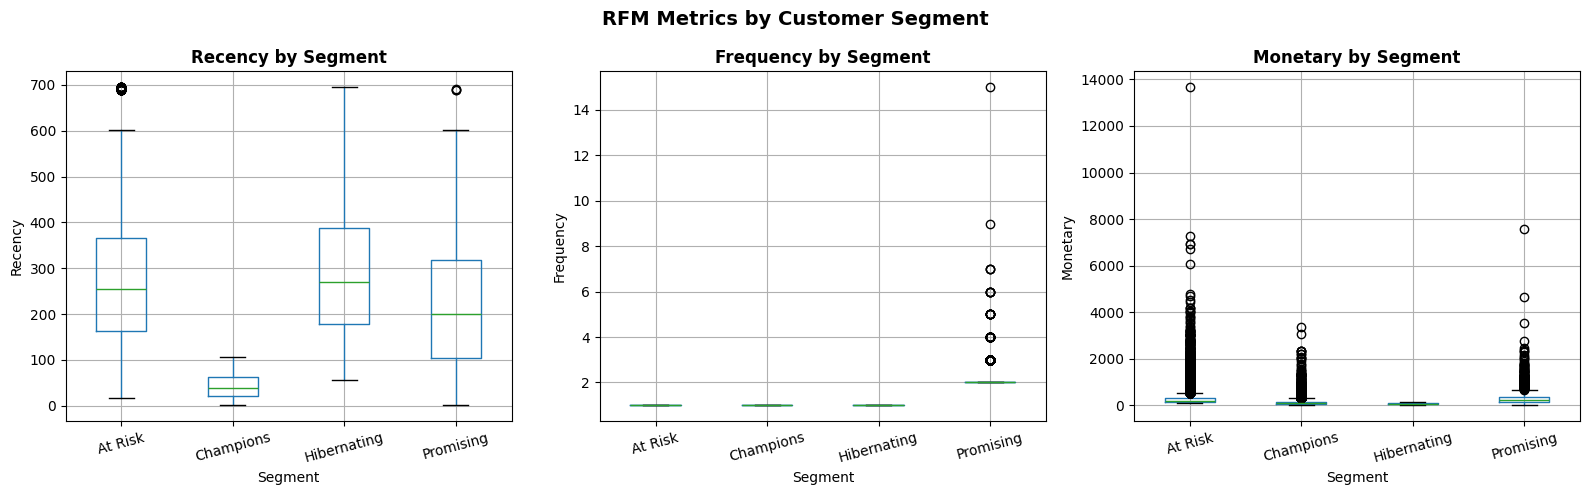

In [24]:
# Boxplot: RFM metrics by segment
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    rfm.boxplot(column=metric, by='Segment', ax=ax)
    ax.set_title(f'{metric} by Segment', fontsize=12, fontweight='bold')
    ax.set_xlabel('Segment')
    ax.set_ylabel(metric)
    plt.sca(ax)
    plt.xticks(rotation=15)

plt.suptitle('RFM Metrics by Customer Segment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

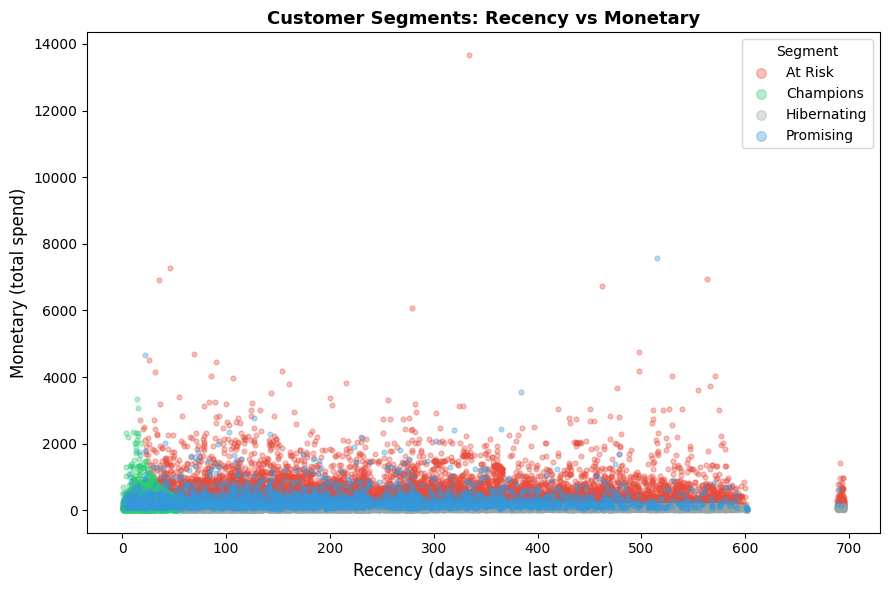

In [25]:
# Scatter: Recency vs Monetary colored by Segment
colors = {'Champions': '#2ecc71', 'At Risk': '#e74c3c', 'Promising': '#3498db', 'Hibernating': '#95a5a6'}

fig, ax = plt.subplots(figsize=(9, 6))
for seg, group in rfm.groupby('Segment'):
    ax.scatter(group['Recency'], group['Monetary'],
               label=seg, alpha=0.35, s=12, color=colors.get(seg, 'grey'))

ax.set_xlabel('Recency (days since last order)', fontsize=12)
ax.set_ylabel('Monetary (total spend)', fontsize=12)
ax.set_title('Customer Segments: Recency vs Monetary', fontsize=13, fontweight='bold')
ax.legend(title='Segment', markerscale=2)
plt.tight_layout()
plt.show()

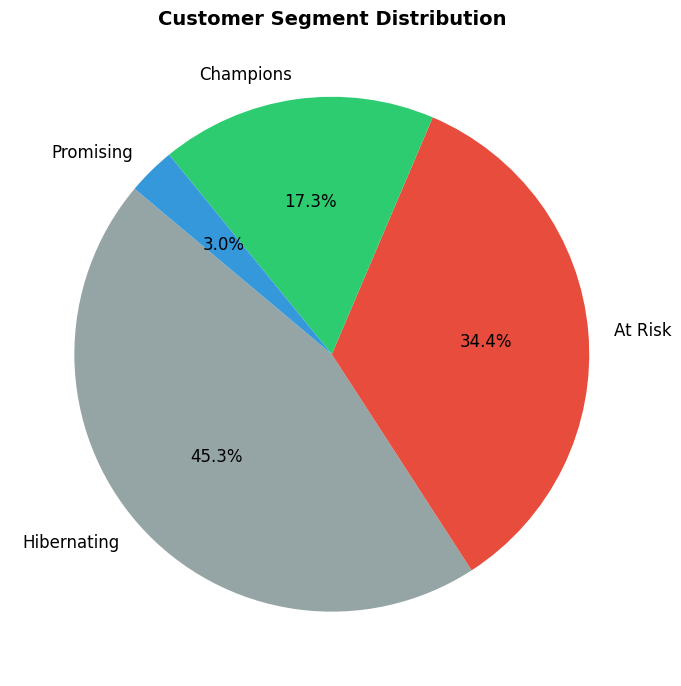

In [26]:
# Pie chart: Segment size distribution
seg_counts = rfm['Segment'].value_counts()
pie_colors = [colors.get(s, '#bdc3c7') for s in seg_counts.index]

plt.figure(figsize=(7, 7))
plt.pie(seg_counts, labels=seg_counts.index, autopct='%1.1f%%',
        colors=pie_colors, startangle=140, textprops={'fontsize': 12})
plt.title('Customer Segment Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Export RFM Results

In [ ]:
import os
os.makedirs('../Data/processed', exist_ok=True)

rfm.to_csv('../Data/processed/rfm_segments.csv', index=False)
print("Saved: ../Data/processed/rfm_segments.csv")
print(f"Final shape: {rfm.shape}")
print(rfm.head())